In [1]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_white_with_border_and_enhanced_points(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3, point_enhance_size=2):
    """
    Change mask background to white, add black border around entire image, 
    small bounding boxes around each point, and enhance point visibility
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
        border_thickness: Thickness of the black border around the entire image
        box_size: Size of the bounding boxes around each point
        point_enhance_size: How much to enlarge the points for better visibility
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to WHITE (255,255,255) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]  # White
                
                # Find non-background points (the actual points we want to put boxes around)
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # First, enhance the points by making them larger
                enhanced_points = np.zeros_like(result_array)
                for y, x in zip(y_coords, x_coords):
                    # Get original point color
                    point_color = result_array[y, x]
                    
                    # Create enhanced point (larger circle)
                    for dy in range(-point_enhance_size, point_enhance_size + 1):
                        for dx in range(-point_enhance_size, point_enhance_size + 1):
                            ny, nx = y + dy, x + dx
                            if (0 <= ny < result_array.shape[0] and 
                                0 <= nx < result_array.shape[1] and 
                                (dx*dx + dy*dy) <= point_enhance_size*point_enhance_size):
                                enhanced_points[ny, nx] = point_color
                
                # Apply enhanced points to result
                enhanced_mask = np.any(enhanced_points != 0, axis=2)
                result_array[enhanced_mask] = enhanced_points[enhanced_mask]
                
                # Draw small bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    # Calculate box coordinates
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box (black rectangle edges)
                    result_array[y1:y2, x1] = box_color        # Left edge
                    result_array[y1:y2, x2-1] = box_color      # Right edge
                    result_array[y1, x1:x2] = box_color        # Top edge
                    result_array[y2-1, x1:x2] = box_color      # Bottom edge
                
                # Add black border around the ENTIRE image
                height, width = result_array.shape[:2]
                
                # Top border
                result_array[0:border_thickness, :] = [0, 0, 0]
                # Bottom border
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                # Left border
                result_array[:, 0:border_thickness] = [0, 0, 0]
                # Right border
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename} - {len(y_coords)} enhanced points with boxes")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Enhanced masks with white background, black border, and point boxes saved to: {output_folder}")

def change_mask_background_to_white_with_border_and_bold_points(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3, point_boldness=2):
    """
    Alternative version: Makes points bolder and more visible
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            with Image.open(input_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to white
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]
                
                # Find non-background points
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # Make points bolder by creating a dark outline around them
                for y, x in zip(y_coords, x_coords):
                    point_color = result_array[y, x]
                    
                    # Create bold point with dark outline
                    for dy in range(-point_boldness, point_boldness + 1):
                        for dx in range(-point_boldness, point_boldness + 1):
                            ny, nx = y + dy, x + dx
                            if (0 <= ny < result_array.shape[0] and 
                                0 <= nx < result_array.shape[1]):
                                # For the outer ring, use darker version of the color
                                if abs(dy) == point_boldness or abs(dx) == point_boldness:
                                    # Darker outline
                                    dark_color = [max(0, c-100) for c in point_color]
                                    result_array[ny, nx] = dark_color
                                else:
                                    # Keep original color for inner part
                                    result_array[ny, nx] = point_color
                
                # Draw bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box edges
                    result_array[y1:y2, x1] = box_color
                    result_array[y1:y2, x2-1] = box_color
                    result_array[y1, x1:x2] = box_color
                    result_array[y2-1, x1:x2] = box_color
                
                # Add black border around entire image
                height, width = result_array.shape[:2]
                result_array[0:border_thickness, :] = [0, 0, 0]
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                result_array[:, 0:border_thickness] = [0, 0, 0]
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed with bold points: {filename} - {len(y_coords)} points")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with bold points saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_point_masks_all_regions_1"
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_point_masks_whitebg_border_boxes_enhanced"
    
    # Method 1: Enhanced points (larger and more visible)
    change_mask_background_to_white_with_border_and_enhanced_points(
        input_folder=input_folder,
        output_folder=output_folder,
        background_color=(100, 100, 100),
        tolerance=0,
        border_thickness=3,
        box_size=3,
        point_enhance_size=2  # Makes points 2 pixels larger in radius
    )
    
    # Method 2: Bold points with dark outline
    # change_mask_background_to_white_with_border_and_bold_points(
    #     input_folder=input_folder,
    #     output_folder=output_folder + "_bold",
    #     background_color=(100, 100, 100),
    #     tolerance=0,
    #     border_thickness=3,
    #     box_size=3,
    #     point_boldness=2  # Adds dark outline around points
    # )

Found 300 images to process
✓ Processed: 251.png - 17 enhanced points with boxes
✓ Processed: 8.png - 21 enhanced points with boxes
✓ Processed: 233.png - 86 enhanced points with boxes
✓ Processed: 73.png - 132 enhanced points with boxes
✓ Processed: 103.png - 45 enhanced points with boxes
✓ Processed: 247.png - 177 enhanced points with boxes
✓ Processed: 180.png - 50 enhanced points with boxes
✓ Processed: 264.png - 61 enhanced points with boxes
✓ Processed: 6.png - 50 enhanced points with boxes
✓ Processed: 130.png - 118 enhanced points with boxes
✓ Processed: 228.png - 34 enhanced points with boxes
✓ Processed: 96.png - 45 enhanced points with boxes
✓ Processed: 236.png - 25 enhanced points with boxes
✓ Processed: 33.png - 66 enhanced points with boxes
✓ Processed: 11.png - 70 enhanced points with boxes
✓ Processed: 275.png - 10 enhanced points with boxes
✓ Processed: 54.png - 77 enhanced points with boxes
✓ Processed: 182.png - 61 enhanced points with boxes
✓ Processed: 32.png - 28

In [1]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_white_with_border_and_enhanced_points(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3, point_enhance_size=2):
    """
    Change mask background to white, add black border around entire image, 
    small bounding boxes around each point, and enhance point visibility
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
        border_thickness: Thickness of the black border around the entire image
        box_size: Size of the bounding boxes around each point
        point_enhance_size: How much to enlarge the points for better visibility
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to WHITE (255,255,255) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]  # White
                
                # Find non-background points (the actual points we want to put boxes around)
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # First, enhance the points by making them larger
                enhanced_points = np.zeros_like(result_array)
                for y, x in zip(y_coords, x_coords):
                    # Get original point color
                    point_color = result_array[y, x]
                    
                    # Create enhanced point (larger circle)
                    for dy in range(-point_enhance_size, point_enhance_size + 1):
                        for dx in range(-point_enhance_size, point_enhance_size + 1):
                            ny, nx = y + dy, x + dx
                            if (0 <= ny < result_array.shape[0] and 
                                0 <= nx < result_array.shape[1] and 
                                (dx*dx + dy*dy) <= point_enhance_size*point_enhance_size):
                                enhanced_points[ny, nx] = point_color
                
                # Apply enhanced points to result
                enhanced_mask = np.any(enhanced_points != 0, axis=2)
                result_array[enhanced_mask] = enhanced_points[enhanced_mask]
                
                # Draw small bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    # Calculate box coordinates
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box (black rectangle edges)
                    result_array[y1:y2, x1] = box_color        # Left edge
                    result_array[y1:y2, x2-1] = box_color      # Right edge
                    result_array[y1, x1:x2] = box_color        # Top edge
                    result_array[y2-1, x1:x2] = box_color      # Bottom edge
                
                # Add black border around the ENTIRE image
                height, width = result_array.shape[:2]
                
                # Top border
                result_array[0:border_thickness, :] = [0, 0, 0]
                # Bottom border
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                # Left border
                result_array[:, 0:border_thickness] = [0, 0, 0]
                # Right border
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename} - {len(y_coords)} enhanced points with boxes")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Enhanced masks with white background, black border, and point boxes saved to: {output_folder}")

def change_mask_background_to_white_with_border_and_bold_points(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3, point_boldness=2):
    """
    Alternative version: Makes points bolder and more visible
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            with Image.open(input_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to white
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]
                
                # Find non-background points
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # Make points bolder by creating a dark outline around them
                for y, x in zip(y_coords, x_coords):
                    point_color = result_array[y, x]
                    
                    # Create bold point with dark outline
                    for dy in range(-point_boldness, point_boldness + 1):
                        for dx in range(-point_boldness, point_boldness + 1):
                            ny, nx = y + dy, x + dx
                            if (0 <= ny < result_array.shape[0] and 
                                0 <= nx < result_array.shape[1]):
                                # For the outer ring, use darker version of the color
                                if abs(dy) == point_boldness or abs(dx) == point_boldness:
                                    # Darker outline
                                    dark_color = [max(0, c-100) for c in point_color]
                                    result_array[ny, nx] = dark_color
                                else:
                                    # Keep original color for inner part
                                    result_array[ny, nx] = point_color
                
                # Draw bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box edges
                    result_array[y1:y2, x1] = box_color
                    result_array[y1:y2, x2-1] = box_color
                    result_array[y1, x1:x2] = box_color
                    result_array[y2-1, x1:x2] = box_color
                
                # Add black border around entire image
                height, width = result_array.shape[:2]
                result_array[0:border_thickness, :] = [0, 0, 0]
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                result_array[:, 0:border_thickness] = [0, 0, 0]
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed with bold points: {filename} - {len(y_coords)} points")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with bold points saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks"
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks/full_test_point_masks_whitebg_enhanced"
    
    # Method 1: Enhanced points (larger and more visible)
    change_mask_background_to_white_with_border_and_enhanced_points(
        input_folder=input_folder,
        output_folder=output_folder,
        background_color=(100, 100, 100),
        tolerance=0,
        border_thickness=3,
        box_size=3,
        point_enhance_size=2  # Makes points 2 pixels larger in radius
    )
    
    # Method 2: Bold points with dark outline
    # change_mask_background_to_white_with_border_and_bold_points(
    #     input_folder=input_folder,
    #     output_folder=output_folder + "_bold",
    #     background_color=(100, 100, 100),
    #     tolerance=0,
    #     border_thickness=3,
    #     box_size=3,
    #     point_boldness=2  # Adds dark outline around points
    # )

Found 1319 images to process
✓ Processed: runwa_1890.png - 15 enhanced points with boxes
✓ Processed: freew_384.png - 45 enhanced points with boxes
✓ Processed: parki_294.png - 58 enhanced points with boxes
✓ Processed: inter_2041.png - 170 enhanced points with boxes
✓ Processed: mediu_1250.png - 172 enhanced points with boxes
✓ Processed: spars_154.png - 55 enhanced points with boxes
✓ Processed: stora_591.png - 60 enhanced points with boxes
✓ Processed: stora_571.png - 50 enhanced points with boxes
✓ Processed: stora_572.png - 35 enhanced points with boxes
✓ Processed: runwa_1849.png - 15 enhanced points with boxes
✓ Processed: golfc_69.png - 45 enhanced points with boxes
✓ Processed: harbo_454.png - 109 enhanced points with boxes
✓ Processed: overp_1542.png - 40 enhanced points with boxes
✓ Processed: tenni_1034.png - 75 enhanced points with boxes
✓ Processed: dense_1433.png - 135 enhanced points with boxes
✓ Processed: freew_339.png - 65 enhanced points with boxes
✓ Processed: rive

In [3]:
import os
import cv2
import numpy as np
from PIL import Image

def overlay_points_with_original_colors_and_boxes(mask_folder, image_folder, output_folder, 
                                                 background_color=(100,100,100), 
                                                 box_size=3, box_color=(0, 255, 0), tolerance=0):
    """
    Overlay points with their original colors from mask + green bounding boxes
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    mask_files = [f for f in os.listdir(mask_folder) 
                  if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(mask_files)} mask files to process")
    
    for mask_filename in mask_files:
        mask_path = os.path.join(mask_folder, mask_filename)
        
        # Find corresponding image
        image_filename = None
        base_name = os.path.splitext(mask_filename)[0]
        for ext in valid_extensions:
            image_path = os.path.join(image_folder, base_name + ext)
            if os.path.exists(image_path):
                image_filename = base_name + ext
                break
        
        if not image_filename:
            print(f"✗ No corresponding image found for mask: {mask_filename}")
            continue
        
        image_path = os.path.join(image_folder, image_filename)
        output_path = os.path.join(output_folder, f"overlay_{mask_filename}")
        
        try:
            # Read images
            mask = cv2.imread(mask_path)
            original_image = cv2.imread(image_path)
            
            if mask is None or original_image is None:
                continue
            
            # Convert to RGB for processing
            mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            
            # Identify BACKGROUND pixels (to ignore)
            if tolerance == 0:
                background_mask = ((mask_rgb[:,:,0] == background_color[0]) & 
                                  (mask_rgb[:,:,1] == background_color[1]) & 
                                  (mask_rgb[:,:,2] == background_color[2]))
            else:
                color_diff = np.abs(mask_rgb - np.array(background_color))
                background_mask = np.all(color_diff <= tolerance, axis=2)
            
            # NON-BACKGROUND = points we want to mark
            non_bg_mask = ~background_mask
            y_coords, x_coords = np.where(non_bg_mask)
            
            # Start with original image
            overlay_img = original_rgb.copy()
            
            # Draw boxes and copy original point colors
            for y, x in zip(y_coords, x_coords):
                # Get original point color from mask
                original_point_color = mask_rgb[y, x]
                
                # Calculate box coordinates
                y1 = max(0, y - box_size)
                y2 = min(overlay_img.shape[0], y + box_size + 1)
                x1 = max(0, x - box_size)
                x2 = min(overlay_img.shape[1], x + box_size + 1)
                
                # Draw green bounding box
                cv2.rectangle(overlay_img, (x1, y1), (x2, y2), box_color, 1)
                
                # Draw point with original color (slightly enhanced for visibility)
                cv2.circle(overlay_img, (x, y), 2, [int(c) for c in original_point_color], -1)
            
            # Convert back to BGR and save
            overlay_bgr = cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, overlay_bgr)
            print(f"✓ Overlay: {mask_filename} - {len(y_coords)} points")
            
        except Exception as e:
            print(f"✗ Error: {mask_filename} - {str(e)}")
    
    print(f"✅ Overlay images with original colors + boxes saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks"
    image_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images" 
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/overlay_test_images" 
    
    print("=== CREATING OVERLAYS WITH ORIGINAL COLORS + BOXES ===")
    overlay_points_with_original_colors_and_boxes(
        mask_folder=mask_folder,
        image_folder=image_folder,
        output_folder=output_folder,
        background_color=(100,100,100),  # Black background to ignore
        box_size=3,                  # Small boxes around points
        box_color=(0, 255, 0),       # Green boxes
        tolerance=0                  # Exact background match
    )

=== CREATING OVERLAYS WITH ORIGINAL COLORS + BOXES ===
Found 1319 mask files to process
✓ Overlay: runwa_1890.png - 15 points
✓ Overlay: freew_384.png - 45 points
✓ Overlay: parki_294.png - 58 points
✓ Overlay: inter_2041.png - 170 points
✓ Overlay: mediu_1250.png - 172 points
✓ Overlay: spars_154.png - 55 points
✓ Overlay: stora_591.png - 60 points
✓ Overlay: stora_571.png - 50 points
✓ Overlay: stora_572.png - 35 points
✓ Overlay: runwa_1849.png - 15 points
✓ Overlay: golfc_69.png - 45 points
✓ Overlay: harbo_454.png - 109 points
✓ Overlay: overp_1542.png - 40 points
✓ Overlay: tenni_1034.png - 75 points
✓ Overlay: dense_1433.png - 135 points
✓ Overlay: freew_339.png - 65 points
✓ Overlay: river_1353.png - 50 points
✓ Overlay: beach_1185.png - 10 points
✓ Overlay: dense_1458.png - 245 points
✓ Overlay: spars_193.png - 175 points
✓ Overlay: freew_354.png - 60 points
✓ Overlay: airpl_859.png - 25 points
✓ Overlay: freew_394.png - 75 points
✓ Overlay: river_1359.png - 45 points
✓ Overla

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image

def overlay_points_with_original_colors_and_boxes(mask_folder, image_folder, output_folder, 
                                                 background_color=(100,100,100), 
                                                 box_size=3, box_color=(0, 255, 0), tolerance=0):
    """
    Overlay points with their original colors from mask + green bounding boxes
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    mask_files = [f for f in os.listdir(mask_folder) 
                  if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(mask_files)} mask files to process")
    
    for mask_filename in mask_files:
        mask_path = os.path.join(mask_folder, mask_filename)
        
        # Find corresponding image
        image_filename = None
        base_name = os.path.splitext(mask_filename)[0]
        for ext in valid_extensions:
            image_path = os.path.join(image_folder, base_name + ext)
            if os.path.exists(image_path):
                image_filename = base_name + ext
                break
        
        if not image_filename:
            print(f"✗ No corresponding image found for mask: {mask_filename}")
            continue
        
        image_path = os.path.join(image_folder, image_filename)
        output_path = os.path.join(output_folder, f"overlay_{mask_filename}")
        
        try:
            # Read images
            mask = cv2.imread(mask_path)
            original_image = cv2.imread(image_path)
            
            if mask is None or original_image is None:
                continue
            
            # Convert to RGB for processing
            mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            
            # Identify BACKGROUND pixels (to ignore)
            if tolerance == 0:
                background_mask = ((mask_rgb[:,:,0] == background_color[0]) & 
                                  (mask_rgb[:,:,1] == background_color[1]) & 
                                  (mask_rgb[:,:,2] == background_color[2]))
            else:
                color_diff = np.abs(mask_rgb - np.array(background_color))
                background_mask = np.all(color_diff <= tolerance, axis=2)
            
            # NON-BACKGROUND = points we want to mark
            non_bg_mask = ~background_mask
            y_coords, x_coords = np.where(non_bg_mask)
            
            # Start with original image
            overlay_img = original_rgb.copy()
            
            # Draw boxes and copy original point colors
            for y, x in zip(y_coords, x_coords):
                # Get original point color from mask
                original_point_color = mask_rgb[y, x]
                
                # Calculate box coordinates
                y1 = max(0, y - box_size)
                y2 = min(overlay_img.shape[0], y + box_size + 1)
                x1 = max(0, x - box_size)
                x2 = min(overlay_img.shape[1], x + box_size + 1)
                
                # Draw green bounding box
                cv2.rectangle(overlay_img, (x1, y1), (x2, y2), box_color, 1)
                
                # Draw point with original color (slightly enhanced for visibility)
                cv2.circle(overlay_img, (x, y), 2, [int(c) for c in original_point_color], -1)
            
            # Convert back to BGR and save
            overlay_bgr = cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, overlay_bgr)
            print(f"✓ Overlay: {mask_filename} - {len(y_coords)} points")
            
        except Exception as e:
            print(f"✗ Error: {mask_filename} - {str(e)}")
    
    print(f"✅ Overlay images with original colors + boxes saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_point_masks_all_regions_1" 
    image_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_images" 
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/point_orig_overlay_train_images" 
    
    print("=== CREATING OVERLAYS WITH ORIGINAL COLORS + BOXES ===")
    overlay_points_with_original_colors_and_boxes(
        mask_folder=mask_folder,
        image_folder=image_folder,
        output_folder=output_folder,
        background_color=(100,100,100),  # Black background to ignore
        box_size=3,                  # Small boxes around points
        box_color=(0, 255, 0),       # Green boxes
        tolerance=0                  # Exact background match
    )

🔍 Checking if all files exist:
   Overlay (overlay_31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/point_orig_overlay_train_images/overlay_31.png - ✅ EXISTS
   WhiteBG (31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_point_masks_whitebg_border_boxes_enhanced/31.png - ✅ EXISTS
   Orig Mask (31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_masks/31.png - ✅ EXISTS

🎯 All files found! Creating composite image with gaps...
📁 Looking for files:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/point_orig_overlay_train_images/overlay_31.png
   WhiteBG: /home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_point_masks_whitebg_border_boxes_enhanced/31.png
   Orig Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_masks/31.png
✅ Successfully loaded all images:
   Overlay shape: (256, 256, 3)
   WhiteBG shape: (256, 256, 3)
   Orig Mask shape: (256, 256, 3)
✅ Composite image with gaps saved: image_3

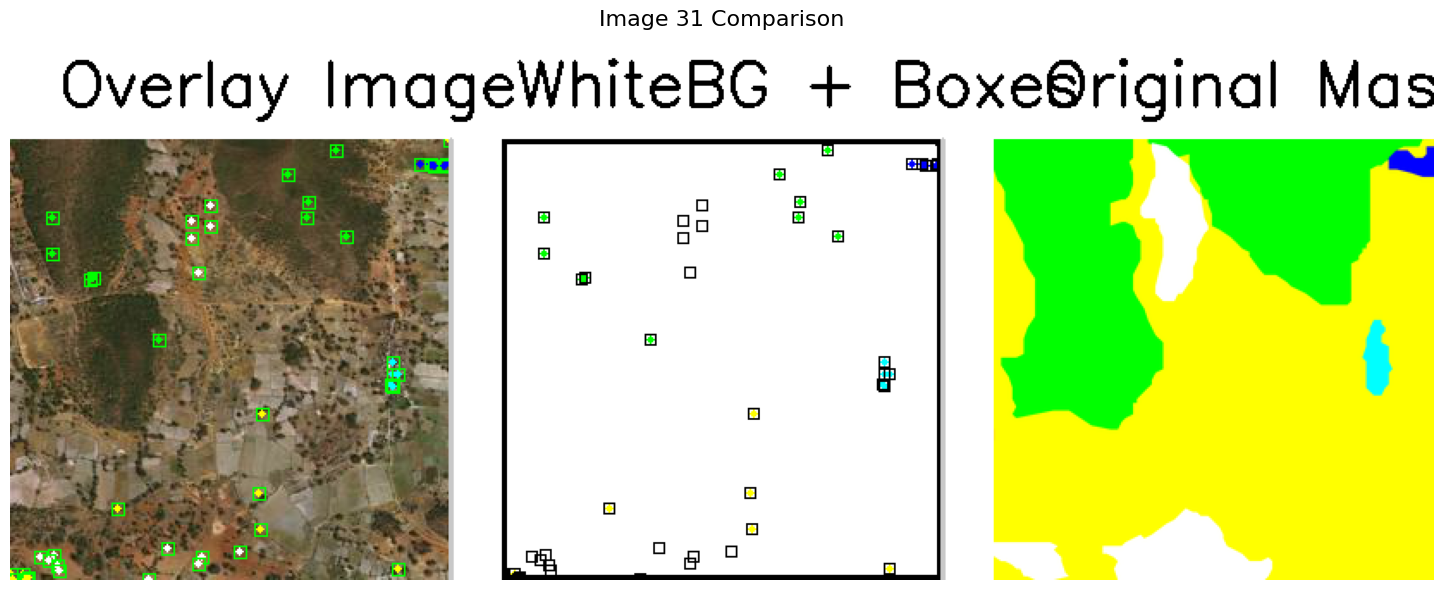

In [4]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def create_comparison_image_31(overlay_folder, whitebg_folder, orig_mask_folder, output_path, base_name="31", gap_size=20):
    """
    Create a horizontal composite of 3 images for image 31 with gaps between them:
    1. Overlay image (overlay_31.png)
    2. Point mask with white background (31.png)
    3. Original mask (31.png)
    """
    
    # Define the specific filenames with different naming patterns
    overlay_filename = f"overlay_{base_name}.png"  # overlay_31.png
    whitebg_filename = f"{base_name}.png"          # 31.png
    orig_mask_filename = f"{base_name}.png"        # 31.png
    
    # Construct full paths
    overlay_path = os.path.join(overlay_folder, overlay_filename)
    whitebg_path = os.path.join(whitebg_folder, whitebg_filename)
    orig_mask_path = os.path.join(orig_mask_folder, orig_mask_filename)
    
    print(f"📁 Looking for files:")
    print(f"   Overlay: {overlay_path}")
    print(f"   WhiteBG: {whitebg_path}")
    print(f"   Orig Mask: {orig_mask_path}")
    
    # Check if all files exist
    if not os.path.exists(overlay_path):
        print(f"❌ Overlay file not found: {overlay_path}")
        return
    if not os.path.exists(whitebg_path):
        print(f"❌ WhiteBG file not found: {whitebg_path}")
        return
    if not os.path.exists(orig_mask_path):
        print(f"❌ Original mask file not found: {orig_mask_path}")
        return
    
    try:
        # Read all three images
        overlay_img = cv2.imread(overlay_path)
        whitebg_img = cv2.imread(whitebg_path)
        orig_mask_img = cv2.imread(orig_mask_path)
        
        if overlay_img is None:
            print("❌ Error reading overlay image")
            return
        if whitebg_img is None:
            print("❌ Error reading whitebg image")
            return
        if orig_mask_img is None:
            print("❌ Error reading original mask image")
            return
        
        print(f"✅ Successfully loaded all images:")
        print(f"   Overlay shape: {overlay_img.shape}")
        print(f"   WhiteBG shape: {whitebg_img.shape}")
        print(f"   Orig Mask shape: {orig_mask_img.shape}")
        
        # Convert BGR to RGB for display
        overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
        whitebg_rgb = cv2.cvtColor(whitebg_img, cv2.COLOR_BGR2RGB)
        orig_mask_rgb = cv2.cvtColor(orig_mask_img, cv2.COLOR_BGR2RGB)
        
        # Resize images to have the same height (maintain aspect ratio)
        target_height = min(overlay_rgb.shape[0], whitebg_rgb.shape[0], orig_mask_rgb.shape[0])
        
        def resize_to_height(img, height):
            h, w = img.shape[:2]
            scale = height / h
            new_w = int(w * scale)
            return cv2.resize(img, (new_w, height))
        
        overlay_resized = resize_to_height(overlay_rgb, target_height)
        whitebg_resized = resize_to_height(whitebg_rgb, target_height)
        orig_mask_resized = resize_to_height(orig_mask_rgb, target_height)
        
        # Create white gaps between images
        gap = np.ones((target_height, gap_size, 3), dtype=np.uint8) * 255  # White gap
        
        # Combine images horizontally with gaps
        composite = np.hstack([
            overlay_resized, 
            gap,  # Gap after first image
            whitebg_resized, 
            gap,  # Gap after second image
            orig_mask_resized
        ])
        
        # Add labels to the composite image
        label_height = 50
        composite_with_labels = np.ones((composite.shape[0] + label_height, composite.shape[1], 3), dtype=np.uint8) * 255
        
        # Place the composite image
        composite_with_labels[label_height:, :] = composite
        
        # Add text labels
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 2
        color = (0, 0, 0)  # Black text
        
        # Calculate label positions (accounting for gaps)
        w1 = overlay_resized.shape[1]
        w2 = whitebg_resized.shape[1]
        w3 = orig_mask_resized.shape[1]
        
        # Position labels under each image (accounting for gaps)
        label1_x = w1 // 2
        label2_x = w1 + gap_size + w2 // 2
        label3_x = w1 + gap_size + w2 + gap_size + w3 // 2
        
        cv2.putText(composite_with_labels, "Overlay Image", (label1_x - 100, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "WhiteBG + Boxes", (label2_x - 120, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Original Mask", (label3_x - 100, 30), font, font_scale, color, thickness)
        
        # Add separator lines at the gap positions
        line_color = (200, 200, 200)  # Light gray lines
        line1_x = w1
        line2_x = w1 + gap_size + w2
        
        cv2.line(composite_with_labels, (line1_x, label_height), (line1_x, composite_with_labels.shape[0]), line_color, 2)
        cv2.line(composite_with_labels, (line2_x, label_height), (line2_x, composite_with_labels.shape[0]), line_color, 2)
        
        # Save the composite image
        cv2.imwrite(output_path, cv2.cvtColor(composite_with_labels, cv2.COLOR_RGB2BGR))
        print(f"✅ Composite image with gaps saved: {output_path}")
        
        # Display the image
        plt.figure(figsize=(20, 6))
        plt.imshow(composite_with_labels)
        plt.axis('off')
        plt.title(f'Image {base_name} Comparison', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error creating composite: {str(e)}")
        import traceback
        traceback.print_exc()

def check_all_files_exist(overlay_folder, whitebg_folder, orig_mask_folder, base_name="31"):
    """
    Check if all required files exist with correct naming patterns
    """
    overlay_path = os.path.join(overlay_folder, f"overlay_{base_name}.png")  # overlay_31.png
    whitebg_path = os.path.join(whitebg_folder, f"{base_name}.png")          # 31.png
    orig_mask_path = os.path.join(orig_mask_folder, f"{base_name}.png")      # 31.png
    
    print("🔍 Checking if all files exist:")
    print(f"   Overlay (overlay_{base_name}.png): {overlay_path} - {'✅ EXISTS' if os.path.exists(overlay_path) else '❌ MISSING'}")
    print(f"   WhiteBG ({base_name}.png): {whitebg_path} - {'✅ EXISTS' if os.path.exists(whitebg_path) else '❌ MISSING'}")
    print(f"   Orig Mask ({base_name}.png): {orig_mask_path} - {'✅ EXISTS' if os.path.exists(orig_mask_path) else '❌ MISSING'}")
    
    return all([os.path.exists(overlay_path), os.path.exists(whitebg_path), os.path.exists(orig_mask_path)])

# Usage
if __name__ == "__main__":
    # Define your folder paths
    overlay_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/point_orig_overlay_train_images"  # Contains overlay_31.png
    whitebg_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_point_masks_whitebg_border_boxes_enhanced"  # Contains 31.png (white background + boxes)
    orig_mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/deepglobe/train_masks"  # Contains 31.png (original mask)
    
    # Output path for the composite image
    output_path = "image_31_comparison_with_gaps.png"
    
    # First, check if all files exist
    if check_all_files_exist(overlay_folder, whitebg_folder, orig_mask_folder, base_name="31"):
        print("\n🎯 All files found! Creating composite image with gaps...")
        # Create the composite image
        create_comparison_image_31(
            overlay_folder=overlay_folder,
            whitebg_folder=whitebg_folder, 
            orig_mask_folder=orig_mask_folder,
            output_path=output_path,
            base_name="31",
            gap_size=30  # Adjust gap size as needed (pixels)
        )
    else:
        print("\n❌ Some files are missing. Please check the paths above.")
        
        # Let's see what files actually exist in each folder
        print("\n📂 Actual files in folders:")
        print(f"Overlay folder files containing '31': {[f for f in os.listdir(overlay_folder) if '31' in f]}")
        print(f"WhiteBG folder files containing '31': {[f for f in os.listdir(whitebg_folder) if '31' in f]}")
        print(f"Orig Mask folder files containing '31': {[f for f in os.listdir(orig_mask_folder) if '31' in f]}")